Задание 1 (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/dev0914sharma/customer-clustering/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('segmentation data.csv')

1.1 Кодирование категориальных признаков, выбираем 7 признаков (2 числовых и 5 категориальных), масштабируем признаки

In [ ]:
categorical_cols = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']
df_enc = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    
features = ['Age', 'Income', 'Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']
X = df_enc[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Провести кластерный анализ данных о клиентах;

2.1 Выбор оптимального числа кластеров (от 2 до 10)

In [ ]:
inertia = []
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

2.2 Визуализация

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Silhouette method')
plt.tight_layout()
plt.show()

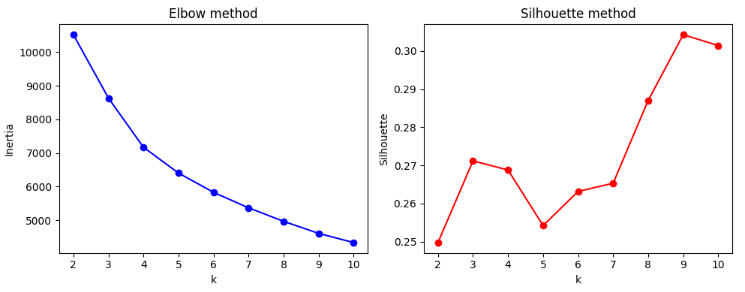

2.3 Финальная кластеризация (оптимально 9)

In [ ]:
optimal_k = 9
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

2.4 Визуализация кластеров

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='Set2', alpha=0.7, s=30)
plt.scatter(kmeans.cluster_centers_ @ pca.components_.T, 
            kmeans.cluster_centers_ @ pca.components_.T, 
            c='red', marker='X', s=200, label='Centers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters visualization (PCA)')
plt.legend()
plt.show()

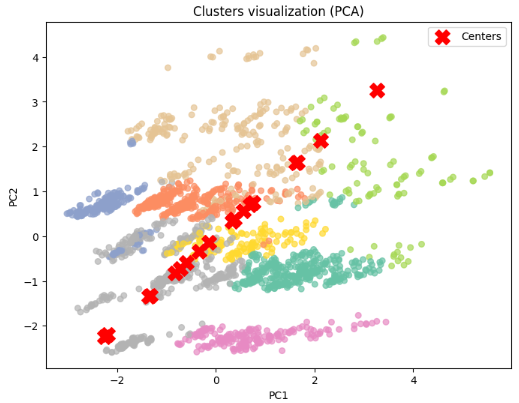

3. Описать профиль всех полученных кластеров.

In [ ]:
print("CLUSTER PROFILES")
profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Income': 'mean',
    'Sex': lambda x: x.mode()[0],
    'Marital status': lambda x: x.mode()[0],
    'Education': lambda x: x.mode()[0],
    'Occupation': lambda x: x.mode()[0],
    'Settlement size': lambda x: x.mode()[0],
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'}).round(1)
print(profile)

for i in range(optimal_k):
    cl = df[df['Cluster'] == i]
    print(f"\nCluster {i} ({len(cl)/len(df)*100:.1f}%):")
    print(f"  Age: {cl['Age'].mean():.1f} yrs, Income: {cl['Income'].mean():.1f}")
    print(f"  Sex: {cl['Sex'].mode()[0]}, Marital: {cl['Marital status'].mode()[0]}")
    print(f"  Education: {cl['Education'].mode()[0]}, Occupation: {cl['Occupation'].mode()[0]}")
    print(f"  Settlement: {cl['Settlement size'].mode()[0]}")

Кластеры

| Cluster  |  Age   |   Income |   Sex  |  Marital status  |  Education  |  Occupation |
|-|-|-|-|-|-|-|                                                              
| 0     |     42.6  |  139408.0    |  0          |       0       |     1     |        1    | 
| 1     |     27.7  |  120053.2    |  1           |      1      |      1     |        1    | 
| 2     |     28.5  |   83898.8   |   1          |       1       |     1      |       0    | 
| 3    |      27.8  |  133548.0   |   0         |        0       |     0      |       1    | 
| 4     |     53.3  |  209883.8  |    0          |       1       |     2      |       2    | 
| 5    |      29.0  |  123856.5  |    0         |        1       |     1       |      1    | 
| 6    |      53.7  |  125926.3  |    1        |         1       |     2       |      1    | 
| 7     |     33.5  |   95789.3   |   1        |         0       |     1      |       0    | 
| 8     |     35.8  |   94683.1   |   0       |          0        |    1      |       0    | 

Кластеры

| Cluster  |     Settlement size  |  Count   | 
|-|-|-|                    
| 0  |                   2   |   334   | 
| 1      |                  0   |   384   | 
| 2          |              0   |   231   | 
| 3          |              2   |   187   | 
| 4           |             2   |   101   | 
| 5          |              2    |  154   | 
| 6           |             0   |   217   | 
| 7              |          0   |   161   | 
| 8              |          0   |   231   | 

Cluster 0 (16.7%):
  Age: 42.6 yrs, Income: 139408.0
  Sex: 0, Marital: 0
  Education: 1, Occupation: 1
  Settlement: 2

Cluster 1 (19.2%):
  Age: 27.7 yrs, Income: 120053.2
  Sex: 1, Marital: 1
  Education: 1, Occupation: 1
  Settlement: 0

Cluster 2 (11.6%):
  Age: 28.5 yrs, Income: 83898.8
  Sex: 1, Marital: 1
  Education: 1, Occupation: 0
  Settlement: 0

Cluster 3 (9.3%):
  Age: 27.8 yrs, Income: 133548.0
  Sex: 0, Marital: 0
  Education: 0, Occupation: 1
  Settlement: 2

Cluster 4 (5.1%):
  Age: 53.3 yrs, Income: 209883.8
  Sex: 0, Marital: 1
  Education: 2, Occupation: 2
  Settlement: 2

Cluster 5 (7.7%):
  Age: 29.0 yrs, Income: 123856.5
  Sex: 0, Marital: 1
  Education: 1, Occupation: 1
  Settlement: 2

Cluster 6 (10.8%):
  Age: 53.7 yrs, Income: 125926.3
  Sex: 1, Marital: 1
  Education: 2, Occupation: 1
  Settlement: 0

Cluster 7 (8.1%):
  Age: 33.5 yrs, Income: 95789.3
  Sex: 1, Marital: 0
  Education: 1, Occupation: 0
  Settlement: 0

Cluster 8 (11.6%):
  Age: 35.8 yrs, Income: 94683.1
  Sex: 0, Marital: 0
  Education: 1, Occupation: 0
  Settlement: 0

3.1 Визуализация

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster', y='Age', data=df, ci=None)
plt.title('Average Age by Cluster')
plt.subplot(1, 2, 2)
sns.barplot(x='Cluster', y='Income', data=df, ci=None)
plt.title('Average Income by Cluster')
plt.tight_layout()
plt.show()

print(f"\nSilhouette score: {silhouette_score(X_scaled, df['Cluster']):.3f}")

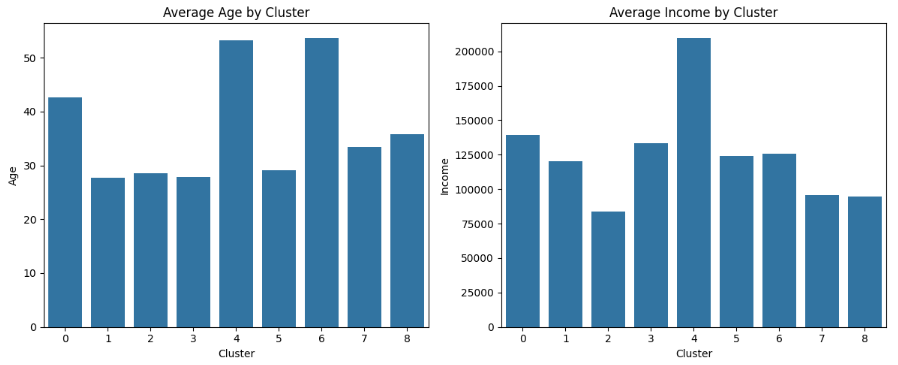

Silhouette score: 0.304